## 요약
* 증가하면 좋은 값: R2, R5, R7
* 감소하면 좋은 값: R0, R1/R4, R3/R9/R10, R8
* R6: 상황에 따라 적절한 수준이 좋음 (특정 기준 없이 증가나 감소로 좋은지를 판단하기 어려움) ==> 이건 어떻게 해야 함..?

## 요약
* 증가하면 좋은 값: Q0, Q1, Q2, Q3
* 이 모든 Q-파라미터들은 높을수록 피부의 회복력과 탄성, 그리고 점탄성의 회복력이 좋다는 것을 의미하므로, 이들 값은 증가할수록 좋음으로 평가할 수 있습니다.

[탄력 측정 기기 관련 링크](https://www.courage-khazaka.com/en/scientific-products/cutometer-dual-mpa-580)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 56.0 MB/s eta 0:00:00


<Axes: title={'center': '한글'}>

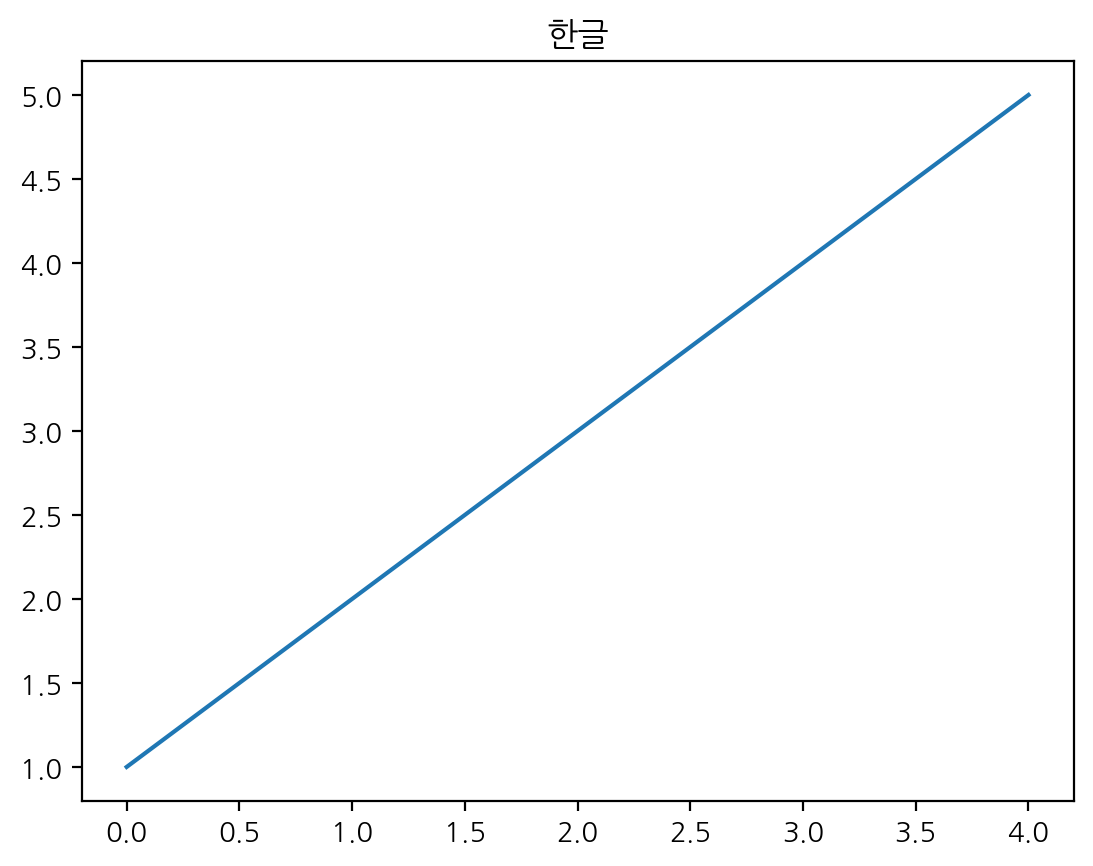

In [3]:
import koreanize_matplotlib

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'
pd.Series([1, 2, 3, 4, 5]).plot(title='한글')

In [4]:
folder_path = '/content/drive/MyDrive/Colab Notebooks/finalPJT/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/'

In [5]:
# 측정 csv 가져오기 #
measurement_raw = pd.read_csv(folder_path+'measurement_data.csv', index_col=0)
measurement = measurement_raw.copy()
print(measurement.shape)
measurement.head(2)

(1072, 80)


,ID,수분_이마,수분_오른쪽볼,수분_왼쪽볼,수분_턱,탄력_턱_R0,탄력_턱_R1,탄력_턱_R2,탄력_턱_R3,탄력_턱_R4,...,주름_오른쪽눈가_Rq,주름_오른쪽눈가_Rmax,주름_오른쪽눈가_R3z,주름_오른쪽눈가_Rt,주름_오른쪽눈가_Rz=Rtm,주름_오른쪽눈가_Rp,주름_오른쪽눈가_Rv,스팟개수_정면,모공개수_오른쪽볼,모공개수_왼쪽볼
0,1,53.0,76.33,71.67,78.67,0.204,0.083,0.5931,0.243,0.123,...,15.760,95.142,41.774,98.502,70.769,46.387,52.115,147,608,629
1,2,75.0,64.00,63.00,66.00,0.279,0.088,0.6846,0.322,0.152,...,18.147,116.790,47.082,122.940,84.142,54.029,68.907,158,691,631


In [6]:
measurement.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1072 entries, 0 to 1071
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1072 non-null   int64  
 1   수분_이마            1072 non-null   float64
 2   수분_오른쪽볼          1072 non-null   float64
 3   수분_왼쪽볼           1072 non-null   float64
 4   수분_턱             1072 non-null   float64
 5   탄력_턱_R0          1072 non-null   float64
 6   탄력_턱_R1          1072 non-null   float64
 7   탄력_턱_R2          1072 non-null   float64
 8   탄력_턱_R3          1072 non-null   float64
 9   탄력_턱_R4          1072 non-null   float64
 10  탄력_턱_R5          1072 non-null   float64
 11  탄력_턱_R6          1072 non-null   float64
 12  탄력_턱_R7          1072 non-null   float64
 13  탄력_턱_R8          1072 non-null   float64
 14  탄력_턱_R9          1072 non-null   float64
 15  탄력_턱_Q0          1072 non-null   float64
 16  탄력_턱_Q1          1072 non-null   float64
 17  탄력_턱_Q2          10

In [7]:
# annotation
annotation_raw = pd.read_csv(folder_path+'annotation_data.csv', index_col=0)
annotation = annotation_raw.copy()
print(annotation.shape)
annotation.head(2)

(2895, 14)


,ID,location,acne,chin_sagging,r_cheek_pore,r_cheek_pigmentation,forehead_wrinkle,r_perocular_wrinkle,l_cheek_pore,glabellus_wrinkle,lip_dryness,forehead_pigmentation,l_cheek_pigmentation,l_perocular_wrinkle
1,1,L,NaN,1.0,2.0,3.0,3.0,2.0,2.0,1.0,1.0,1.0,3.0,3.0
0,1,F,NaN,1.0,2.0,3.0,3.0,2.0,2.0,1.0,1.0,1.0,3.0,3.0


In [8]:
def keyword_df(df, keyword):
    # keyword가 포함된 컬럼명 필터링
    keyword_columns = [col for col in df.columns if keyword in col]

    # 필터링된 컬럼들로 새로운 데이터프레임 생성
    filtered_df = df[['ID'] + keyword_columns]

    return filtered_df

# 탄력 - 턱

In [18]:
chin_elasticity = keyword_df(measurement, '탄력_턱')
chin_elasticity = chin_elasticity.iloc[:, :-4]
chin_elasticity = chin_elasticity.drop(columns=['탄력_턱_R6', '탄력_턱_R0', '탄력_턱_R1', '탄력_턱_R3', '탄력_턱_R4', '탄력_턱_R8', '탄력_턱_R9'])
print(chin_elasticity.shape)
chin_elasticity.head(2)

(1072, 4)


,ID,탄력_턱_R2,탄력_턱_R5,탄력_턱_R7
0,1,0.5931,0.6306,0.3431
1,2,0.6846,0.5657,0.3548


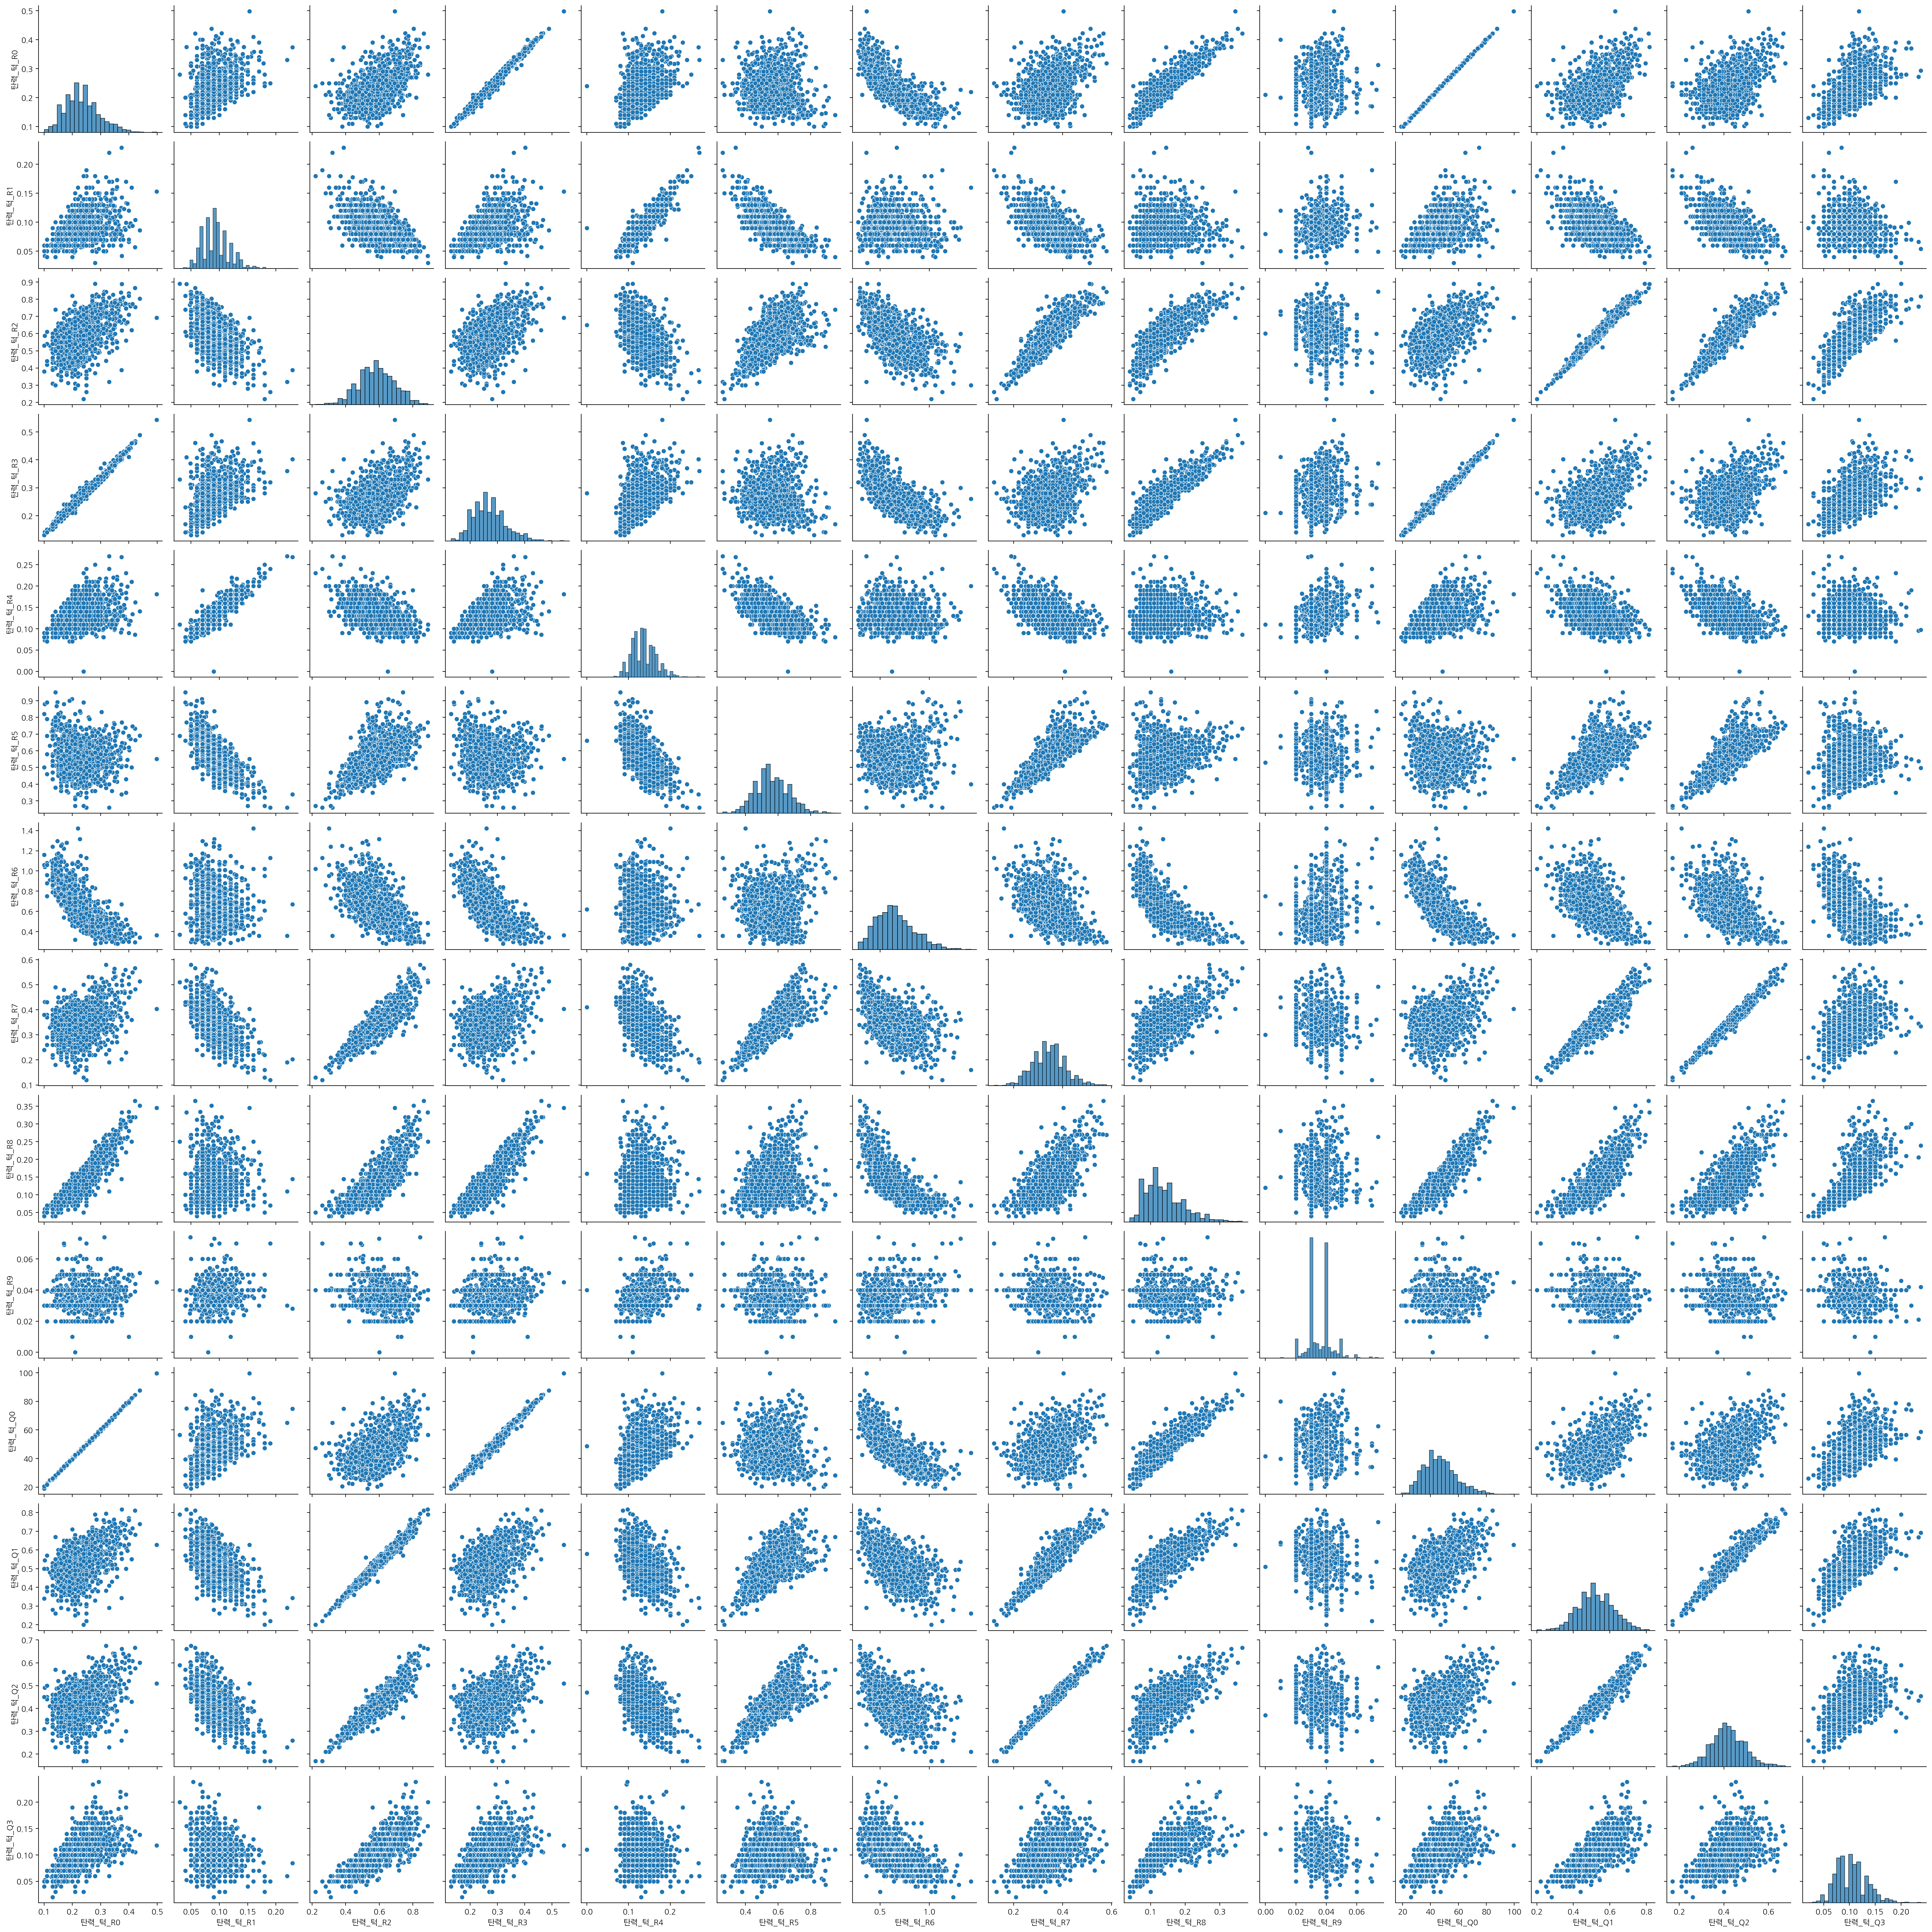

In [ ]:
data = chin_elasticity.iloc[:, 1:]

sns.pairplot(data)

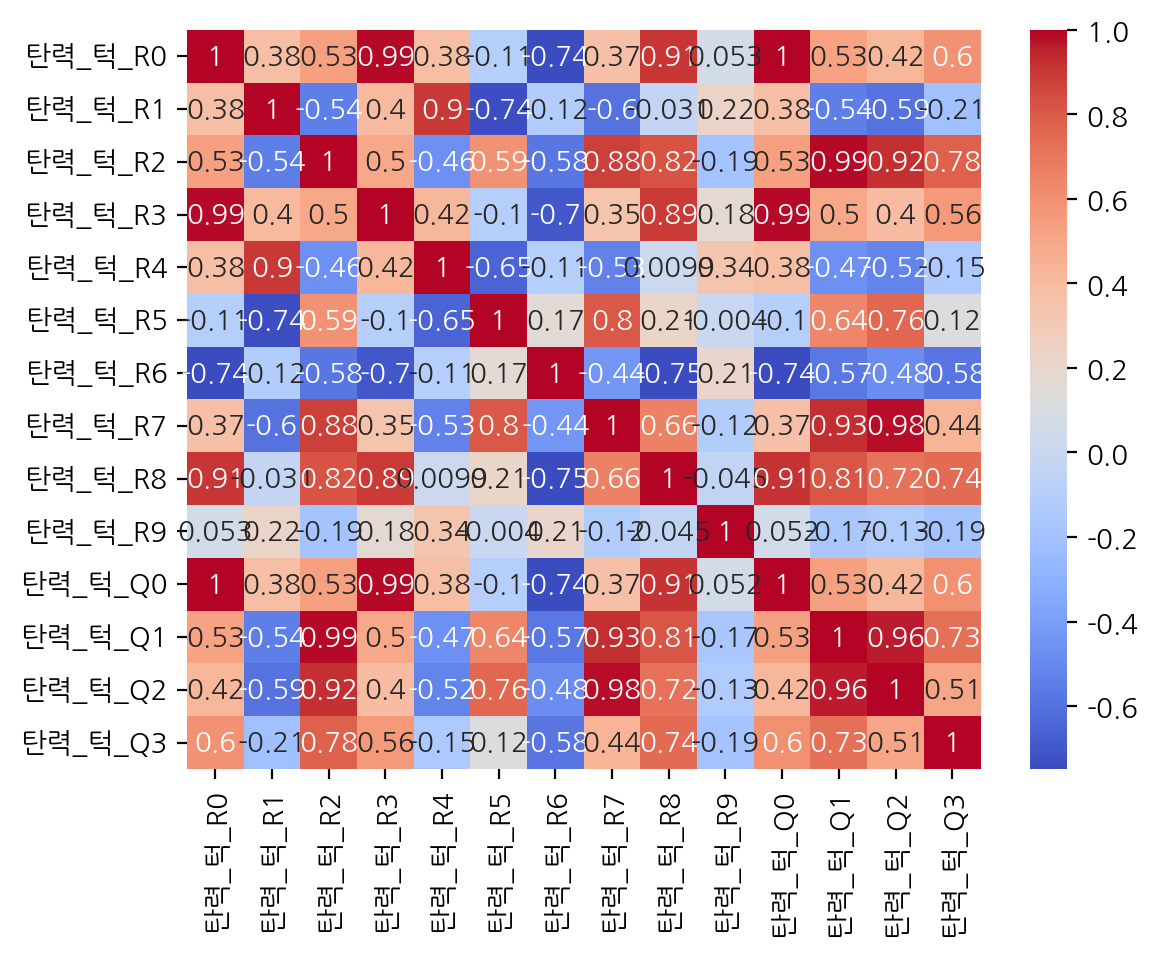

In [ ]:
# 상관 행렬 시각화
correlation_matrix = chin_elasticity.iloc[:, 1:].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [15]:
def scaling(df):
    scaled_df = df.copy()

    scaled_df['탄력_턱_Q0'] = df['탄력_턱_Q0'] / 100

    return scaled_df

In [13]:
from sklearn.decomposition import PCA

def check_pca(df, n):

    # 정규화된 df에서 값 추출
    X = df.iloc[:, 1:]

    pca = PCA(n_components=n)
    principal_components = pca.fit_transform(X)

    # 결과 출력
    print("원래 데이터의 차원 수:", X.shape[1])
    print("PCA 이후의 차원 수:", principal_components.shape[1])
    print("설명된 분산 비율:", pca.explained_variance_ratio_, '합:', pca.explained_variance_ratio_.sum())

    # 주성분 로딩스 확인
    loadings = pd.DataFrame(data=pca.components_.T, index=X.columns)

    return loadings, principal_components

In [20]:
chin_loadings, chin_principal_components = check_pca(chin_elasticity, 0.80)

원래 데이터의 차원 수: 3
PCA 이후의 차원 수: 1
설명된 분산 비율: [0.81853767] 합: 0.8185376748065105


In [21]:
chin_loadings

,0
탄력_턱_R2,-0.650678
탄력_턱_R5,-0.612488
탄력_턱_R7,-0.448861


## 탄력 이마

In [22]:
forehead_elasticity = keyword_df(measurement, '탄력_이마')

forehead_elasticity = forehead_elasticity.iloc[:, :-4]
forehead_elasticity = forehead_elasticity.drop(columns=['탄력_이마_R6', '탄력_이마_R0', '탄력_이마_R1', '탄력_이마_R3', '탄력_이마_R4', '탄력_이마_R8', '탄력_이마_R9'])

print(forehead_elasticity.shape)
forehead_elasticity.head(2)

(1072, 4)


,ID,탄력_이마_R2,탄력_이마_R5,탄력_이마_R7
0,1,0.6527,0.7647,0.3892
1,2,0.6620,0.5517,0.3345


In [23]:
forehead_loadings, forehead_principal_components = check_pca(forehead_elasticity, 0.80)

원래 데이터의 차원 수: 3
PCA 이후의 차원 수: 1
설명된 분산 비율: [0.81031265] 합: 0.8103126462950714


In [24]:
forehead_loadings

,0
탄력_이마_R2,-0.581313
탄력_이마_R5,-0.700617
탄력_이마_R7,-0.413776


## 탄력 왼쪽볼

In [29]:
l_cheek_elasticity = keyword_df(measurement, '탄력_왼쪽볼')

l_cheek_elasticity = l_cheek_elasticity.iloc[:, :-4]
l_cheek_elasticity = l_cheek_elasticity.drop(columns=['탄력_왼쪽볼_R6', '탄력_왼쪽볼_R0', '탄력_왼쪽볼_R1', '탄력_왼쪽볼_R3', '탄력_왼쪽볼_R4', '탄력_왼쪽볼_R8', '탄력_왼쪽볼_R9'])

print(l_cheek_elasticity.shape)
l_cheek_elasticity.head(2)

(1072, 4)


,ID,탄력_왼쪽볼_R2,탄력_왼쪽볼_R5,탄력_왼쪽볼_R7
0,1,0.6364,0.7091,0.3732
1,2,0.6463,0.6594,0.3699


In [30]:
l_cheek_loadings, l_cheek_principal_components = check_pca(l_cheek_elasticity, 0.80)

원래 데이터의 차원 수: 3
PCA 이후의 차원 수: 1
설명된 분산 비율: [0.85739512] 합: 0.8573951223926103


In [31]:
l_cheek_loadings

,0
탄력_왼쪽볼_R2,0.596758
탄력_왼쪽볼_R5,0.666274
탄력_왼쪽볼_R7,0.447168


## 탄력 오른쪽볼

In [32]:
r_cheek_elasticity = keyword_df(measurement, '탄력_오른쪽볼')

r_cheek_elasticity = r_cheek_elasticity.iloc[:, :-4]
r_cheek_elasticity = r_cheek_elasticity.drop(columns=['탄력_오른쪽볼_R6', '탄력_오른쪽볼_R0', '탄력_오른쪽볼_R1', '탄력_오른쪽볼_R3', '탄력_오른쪽볼_R4', '탄력_오른쪽볼_R8', '탄력_오른쪽볼_R9'])

print(r_cheek_elasticity.shape)
r_cheek_elasticity.head(2)

(1072, 4)


,ID,탄력_오른쪽볼_R2,탄력_오른쪽볼_R5,탄력_오른쪽볼_R7
0,1,0.6522,0.6457,0.3565
1,2,0.6331,0.6335,0.3669


In [33]:
r_cheek_loadings, r_cheek_principal_components = check_pca(r_cheek_elasticity, 0.80)

원래 데이터의 차원 수: 3
PCA 이후의 차원 수: 1
설명된 분산 비율: [0.87982181] 합: 0.8798218115944745


In [34]:
r_cheek_loadings

,0
탄력_오른쪽볼_R2,0.598180
탄력_오른쪽볼_R5,0.666171
탄력_오른쪽볼_R7,0.445417
